In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


pd.options.display.float_format = '{:.4f}'.format
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"

# Assignment 2

## Exercise 1: Initial Setup and computing the cluster centre and radii

## 1.a.

(to delete later for conservative space in notebook)

(a) First, load in the stars data as shown in Assignment 1. Then load the list of clusters in assignment2_clusters.dat
into a pandas Series object. To assign a cluster, write down the last four digits of your StudentID 𝑘, and compute
your unique cluster ID using those numbers and the length of the list you loaded from
assignment2_clusters.dat :

cluster_index = k % len(assigment2_clusters)

cluster_name = assigment2_clusters.iloc[cluster_index]

Here, the % symbol computes the modulo (remainder after dividing k by the length of the cluster dataframe). In your
notebook, be sure you note down k, the cluster index and the name of the cluster you will be working with.

In [2]:
gaia_file = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits'
new_clusters = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/assignment2_clusters.dat'

# code given for previous assignment
dr3stars = fits.open(gaia_file)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()
# for the cluster 
new_cluster_series = pd.read_csv(new_clusters, delimiter=',')['0']
# my specs 
k = 7943
cluster_index = k % len(new_cluster_series)
cluster_name = new_cluster_series.loc[cluster_index]
print(f'Cluster index: {cluster_index}, Cluster name: {cluster_name}')


Cluster index: 77, Cluster name: NGC_2658


**Noting:** 
- Last four digits of my Student ID number ($k$): 7943
- cluster index = 77
- cluster name = NGC_2658

In [3]:
# defining my new cluster
my_cluster = stars[stars['Name']=='NGC_2658'].copy()
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
439834,NGC_2658,4600,5639494885187879296,0,0.4791,130.9418,0.0657,-32.6082,0.0829,254.5567,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439835,NGC_2658,4600,5639494889487691008,1,0.9627,130.9349,0.0128,-32.6137,0.0166,254.5575,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439836,NGC_2658,4600,5639494958207185920,1,0.8195,130.8966,0.0225,-32.6238,0.0266,254.5456,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439837,NGC_2658,4600,5639494889487693440,0,0.4454,130.9342,0.0325,-32.6169,0.0403,254.5597,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439838,NGC_2658,4600,5639494919547578496,0,0.3950,130.8823,0.0977,-32.6314,0.1197,254.5442,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440674,NGC_2658,4600,5639416819859780864,0,0.3813,130.5385,0.1724,-32.5645,0.2231,254.3129,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440675,NGC_2658,4600,5639416927234441984,0,0.3757,130.4790,0.1515,-32.5787,0.1781,254.2934,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440676,NGC_2658,4600,5639418679588354048,0,0.3365,130.3096,0.0164,-32.6002,0.0224,254.2233,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440677,NGC_2658,4600,5639420225776518400,0,0.3380,130.4367,0.0110,-32.5335,0.0142,254.2356,...,5.0000,13.4179,0.0614,24.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0


## 1.b.

Use the functions provided in the helper Python script to compute a cluster centre on the sphere and angular
separations for each star from that centre. From there, you can compute the projected radius in arcmin for each star:

$$ R_i = 60 \times \theta_i \times \frac{180}{\pi} $$
where $$ \theta_i = \text{angular\_separation(•)} $$

In [4]:
# obviously taken from the assignment2.py
def spherical_center(ra_deg, dec_deg):
    """
    Compute a centre on the celestial sphere by averaging unit vectors.

    Parameters
    ----------
    ra_deg, dec_deg : float, float
        The RA and Dec in degrees

    Returns
    -------
    ra0, dec0 : float, float
        The centre RA and Dec in degrees
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
    r = np.sqrt(xm**2 + ym**2 + zm**2)
    xm, ym, zm = xm/r, ym/r, zm/r

    dec0 = np.arcsin(zm)
    ra0 = np.arctan2(ym, xm) % (2*np.pi)

    return np.rad2deg(ra0), np.rad2deg(dec0)

# also from assignment2.py
def angular_separation(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """
    Compute the Great-circle angular separation in radians.

    Parameters
    ----------
    ra_deg, dec_deg : iterable, iterable
        RA and Dec values in degrees of an iterable of stars

    ra0_deg, dec0_deg : float, float
        RA and Dec values of the cluster centre

    Returns
    -------
    ang_sep : float
        The angular separation in radians
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    cosang = np.sin(dec)*np.sin(dec0) + np.cos(dec)*np.cos(dec0)*np.cos(ra - ra0)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang_sep = np.arccos(cosang)
    return ang_sep

# •••••••••••• Applying functions to my cluster specifically ••••••••••••

# compute centre using function and print coordinates
sph_center = spherical_center(ra_deg = my_cluster['RAdeg'], 
                              dec_deg = my_cluster['DEdeg'])
print(f'cluster centre coordinates: ' 
      f'RA = {sph_center[0]:.3f} deg, '
      f'Dec = {sph_center[1]:.3f} deg')

# compute angular separation iterating through cluster dataframe
# then add new column of separations to dataframe for each star

# start empty lists 
ang_seps = []
proj_radii= []
# iterate through all stars in cluster
for i in range(len(my_cluster)): 
    # get angular separations
    ang_sep_i = angular_separation(ra_deg = my_cluster.iloc[i]['RAdeg'], 
                                dec_deg = my_cluster.iloc[i]['DEdeg'], 
                                ra0_deg = sph_center[0], 
                                dec0_deg = sph_center[1]) # [deg]
    # get projected radii at each star 
    proj_radius_i = 60*ang_sep_i*180/np.pi # [arcmin]
    # save to arrays
    ang_seps.append(ang_sep_i)
    proj_radii.append(proj_radius_i)
    
# add to cluster dataframe
my_cluster['ang_seps'] = ang_seps
my_cluster['proj_radii'] = proj_radii

print(f'projected radii: {proj_radii}')
print(f'angular separations series: {ang_seps}')

my_cluster[['Name', 'ang_seps', 'proj_radii']]

cluster centre coordinates: RA = 130.869 deg, Dec = -32.645 deg
projected radii: [4.296679334841196, 3.826730318517603, 1.8945135487896136, 3.700059491291081, 1.0644037470233132, 1.768076757863288, 1.1764235584404912, 1.2112043956250156, 2.0232351710126912, 1.4230127271238204, 3.219401487176055, 2.128281818630519, 3.3311942449272607, 3.4984000587139437, 3.1594530449820706, 2.8673777542321623, 3.9182753905352037, 3.264358251139649, 3.2147813348557936, 4.102752055521976, 3.724936781480743, 2.5141133019182553, 3.115151142820934, 1.9949327104822587, 3.862119622305949, 2.1970914081234834, 2.280555536316874, 2.5933324955814463, 1.9499992541937283, 2.0363937776800984, 1.86281808362462, 2.8809879543409322, 2.913298822574903, 3.1447181549110943, 3.0854953400121072, 1.9908289226601448, 1.395756725916869, 1.7996023642615442, 1.8303938032748615, 2.0326518543282526, 1.660723375638422, 1.475344823758454, 2.3035057520214313, 2.6969817328758685, 2.499210312232651, 2.1043746528259226, 3.450863114646296

,Name,ang_seps,proj_radii
439834,NGC_2658,0.0012,4.2967
439835,NGC_2658,0.0011,3.8267
439836,NGC_2658,0.0006,1.8945
439837,NGC_2658,0.0011,3.7001
439838,NGC_2658,0.0003,1.0644
...,...,...,...
440674,NGC_2658,0.0051,17.3981
440675,NGC_2658,0.0059,20.1177
440676,NGC_2658,0.0083,28.4042
440677,NGC_2658,0.0067,22.8651


#### 1.b.i. *Make a scatter plot of RA vs Dec with the center marked*

In [5]:
def plot_my_cluster(plotsize, units):
    """ 
    plots my cluster in degrees or arcminutes because I wanted to look at it later
    and the analysis is based on radial projection in arcminutes
    inputs: plot dimensions (figsize), units = 'deg' or 'arcmin' 
    outputs: the scatter plot of my cluster in either degrees or arcminutes
    ** be sure to set the function equal to an object, otherwise it prints the plot twice
    """
    cluster_plot, ax = plt.subplots(figsize = plotsize)
    if units == 'deg':
        ax.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], marker = '.', label = 'stars')
        ax.axvline(sph_center[0], ls = 'dashed', lw = 1, color = 'violet')
        ax.axhline(sph_center[1], ls = 'dashed', lw = 1, color = 'gold')
        ax.scatter(sph_center[0], sph_center[1], label = 'cluster centre', zorder=3)
        ax.set_xlabel('RA [deg]')
        ax.set_ylabel('Dec [deg]')
        ax.legend()
        ax.set_title('RA vs. DEC Scatter Plot')
    
    elif units == 'arcmin': 
        ax.scatter(60*my_cluster['RAdeg'], 60*my_cluster['DEdeg'], marker = '.', label = 'stars')
        ax.axvline(60*sph_center[0], ls = 'dashed', lw = 1, color = 'violet')
        ax.axhline(60*sph_center[1], ls = 'dashed', lw = 1, color = 'gold')
        ax.scatter(60*sph_center[0], 60*sph_center[1], label = 'cluster centre', zorder=3)
        ax.set_xlabel('RA [arcmin]')
        ax.set_ylabel('Dec [arcmin]')
        ax.legend()
        ax.set_title('RA vs. DEC Scatter Plot')

        # --- grid + ticks ---
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.yaxis.set_major_locator(MultipleLocator(10))

        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6)
        ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.4)

        ax.ticklabel_format(style='sci', axis='both', scilimits=(-2,2))
    
    return cluster_plot

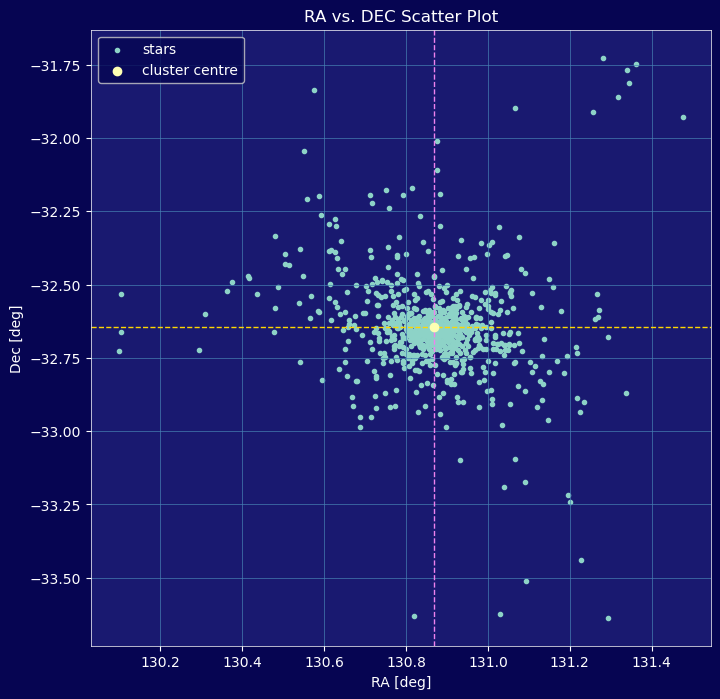

In [6]:
plot_deg = plot_my_cluster((8,8), 'deg')

In [7]:
print(f'total number of stars: {len(my_cluster)}')

total number of stars: 845


#### 1.b.ii *Comment on any structure you see in the scatter plot and how this might affect a radially binned profile.*

It seems that the cluster is generally pretty uniformly distributed in structure. However: 
- RA: I do see a slightly larger variance in Right Ascension on the left side of the cluster (evident with stars at the lower edge (< 130.2 deg), and also in the right-ward skew of the RA center coordinate (pink dashed line)). 

- DEC: 
        
    * i. to the left of center, there is slight asymmetry below and above the declination centre line (slightly more uniformly distributed along a 45 degree line from center towards upper left quadrant than the lower left quadrant, more densely clustered in center)

    * ii. to the right of center, there is a higher variance in declination than on the left side 

- overall, the cluster's structure tends to lie more prominently in the three regions encapsulated by ($\text{RA} \gt \text{RA}_{center}$ and $\text{DEC} \gt \text{DEC}_{center}$) 

- this might affect a radially binned profile by skewing distributions into this region and only being representative along certain slices 

- however now I realize if it is radial, then these three arm-looking structures, if the general distribution amongst them is isotropic, then radial binning should be fine. 

### 1.c. 
*We will now bin the stellar radii into a radial density profile by gathering all stars in annuli (donut-shaped area between two bounds $R_j$ and $R_{j+1}$). First, predict: How will the number of low-count bins change when going from $J = 15$ to $J = 50$ bins? Give a specific numeric expectation (e.g. “I expect the number of bins with counts $𝑁 < 5$ to increase by $X$ amount”) and justify your prediction using the scatter plot you’ve made.*

Answer: 

Here's what I know so far: there are 845 stars in my sample, and the scatter plot seems to show a spatial distribution that seems to increase exponentially in density towards the center coordinates (like if I were to draw a 45 degree line from the center outwards to the corners of my plots). 

With 15 bins, I anticipate the majority of the stars to be inside of the first (innermost radial) bin (~ 500), with the next 200 or so in the second innermost bin, and the final ~150 distributed within bins 3-6 and <30 in the bins 7-15, with the outermost bins having $N \lt 10$. 

From 15 to 50 bins, I anticipate that the number of bins with counts N < 5 to increase by a factor ~ 3.3 (50/15). I am looking at the scatter plot again, and when I don't divide by the center lines, I see that the cluster itself looks like it might have three arms, or at least three locations of outer density: 
1. Right of RA center \& above DEC center, 
2. Right of RA center \& below DEC center, 
3. left of RA center along DEC center line. 

These three dense spots actually seem pretty uniformly distributed (not exponential like the inner parts) so I would assume a linear (so just by factor 50/15) change in the low-count bins rather than a logarithmic one. 

### 1.d.

Set the maximum radius $R_{max}$ to the largest angular projected radius, and define bin edges 0 = $R_0 \lt R_1 \lt \cdots \lt R_J = R_{max}$. Make radial profiles for both $J = 15$ and $J = 50$. For each profile compute: 

* star counts $N_j$ for each annulus $j$ 

* the annulus area $A_j = \pi(R_{j + 1}^2 - R_j^2)(\text{arcmin}^2)$

* mid-radius $R_{j, mid} = \frac{(R_{j + 1}^2  + R_j^2)}{2}$

* empirical surface density: $\hat \Sigma_j = \frac{N_j}{A_j}$

* how many bins satisfy $N_j \lt 1$, $N_j \lt 5$, and $N_j \lt 10$



Just to keep track of the math: 
* defining the bins as instructed means that each bin j has stars with $R_j \leq R \leq R_{j + 1}$
* so, the edges array will have length $J + 1$

In [8]:
# set R_max 
Rmax = max(my_cluster['proj_radii'])
# set bin numbers
J_15 = 15
J_50 = 50
# define bin edges as arrays
bin_array_15 = np.linspace(0, Rmax, J_15 + 1)
bin_array_50 = np.linspace(0, Rmax, J_50 + 1)

I know I am kind of re-inventing the wheel in this next cell (as in there are much easier ways of doing this), but for some reason I decided to do it all out like this. 

In [9]:
def count_stars_annulus(bin_edges_array, cluster, print_counts = True): 

    ''' INPUT DOCSTRING'''

    num_bins = len(bin_edges_array) - 1
    # setting up bin outputs for future list making
    bin_counts = np.zeros(num_bins, dtype=int)
    annulus_areas = np.zeros(num_bins, dtype = float)
    mid_radii = np.zeros(num_bins, dtype = float)
    surface_densities = np.zeros(num_bins, dtype = float)
    stars_binned = []

    # pulling out only relevant pieces of dataframe for this loop 
    names_proj_radii = cluster[['Name', 'proj_radii']] # dataframe of interest

    for j in range(num_bins): 
        # define annulus 
        inner_annulus_boundary = bin_edges_array[j]
        outer_annulus_boundary = bin_edges_array[j+1]
        annulus_area = np.pi*(outer_annulus_boundary**2 - inner_annulus_boundary**2)
        annulus_areas[j] = annulus_area
        mid_radii[j] = (outer_annulus_boundary + inner_annulus_boundary)/2
        # now doing counting 
        stars_in_bin = (names_proj_radii['proj_radii'] >= inner_annulus_boundary) & (names_proj_radii['proj_radii'] < outer_annulus_boundary)
        bin_counts[j] = np.sum(stars_in_bin)
        binned_stars_with_names = names_proj_radii.loc[stars_in_bin]
        stars_binned.append(binned_stars_with_names)
        # calculate surface density 
        surface_densities[j] = bin_counts[j]/annulus_area

    question_1d_dict = {'bin counts': bin_counts, 
                        'annulus areas': annulus_areas, 
                        'mid-radii': mid_radii, 
                        'surface density': surface_densities, 
                        'stars in bins': stars_binned}
    
    binning_dataframe_nonames = pd.DataFrame(question_1d_dict).drop(columns = 'stars in bins') 

    N_less_than_1 = np.sum(bin_counts < 1)
    N_less_than_5 = np.sum(bin_counts < 5)
    N_less_than_10 = np.sum(bin_counts < 10)

    low_counts = [N_less_than_1, 
                  N_less_than_5, 
                  N_less_than_10]
    
    if print_counts == True:
        print(f'N < 1: {low_counts[0]}')
        print(f'N < 5: {low_counts[1]}')
        print(f'N < 10: {low_counts[2]}')

    return binning_dataframe_nonames, low_counts, question_1d_dict


In [12]:
binning_15, _, __ = count_stars_annulus(bin_array_15, my_cluster, print_counts=True)
print('15-bin results: ')
binning_15

N < 1: 0
N < 5: 6
N < 10: 8
15-bin results: 


,bin counts,annulus areas,mid-radii,surface density
0,343,55.6926,2.1052,6.1588
1,210,167.0778,6.3156,1.2569
2,122,278.4630,10.5260,0.4381
3,57,389.8481,14.7364,0.1462
4,48,501.2333,18.9468,0.0958
5,22,612.6185,23.1572,0.0359
6,17,724.0037,27.3676,0.0235
7,4,835.3889,31.5780,0.0048
8,1,946.7741,35.7884,0.0011
9,7,1058.1592,39.9988,0.0066


In [13]:
binning_50, _, __ = count_stars_annulus(bin_array_50, my_cluster, print_counts=True)
print('50-bin results (trunc):')
binning_50.head(15)

N < 1: 12
N < 5: 28
N < 10: 34
50-bin results (trunc):


,bin counts,annulus areas,mid-radii,surface density
0,62,5.0123,0.6316,12.3695
1,126,15.0370,1.8947,8.3793
2,124,25.0617,3.1578,4.9478
3,86,35.0863,4.4209,2.4511
4,73,45.1110,5.6840,1.6182
5,48,55.1357,6.9472,0.8706
6,49,65.1603,8.2103,0.7520
7,45,75.1850,9.4734,0.5985
8,32,85.2097,10.7365,0.3755
9,30,95.2343,11.9997,0.3150


### 1e: *Make the following plots:*
* *$\hat \Sigma_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{\frac{N_j}{A_j}}$*

* *$N_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{N}$*

Note: these are good approximate uncertainties because this data is Poisson-distributed. 


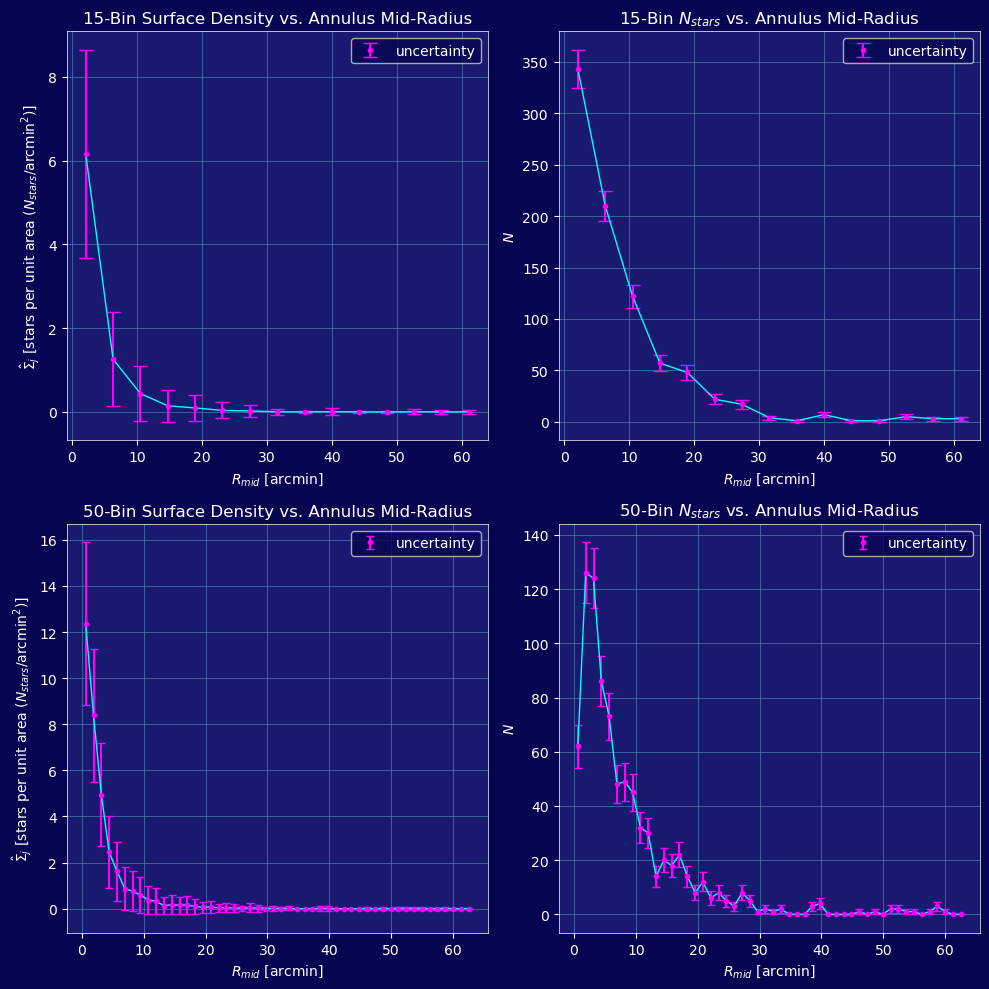

In [14]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))

ax[0,0].errorbar(binning_15['mid-radii'], binning_15['surface density'], 
               yerr=np.sqrt(binning_15['bin counts']/binning_15['annulus areas']), 
               fmt='.', color = 'magenta', capsize = 5, label = 'uncertainty')
ax[0,0].plot(binning_15['mid-radii'], binning_15['surface density'], color = 'cyan', lw = 1)
ax[0,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[0,0].set_title('15-Bin Surface Density vs. Annulus Mid-Radius')
ax[0,0].legend()

ax[0,1].errorbar(binning_15['mid-radii'], binning_15['bin counts'], 
               yerr=np.sqrt(binning_15['bin counts']), 
               fmt='.', color = 'magenta', capsize = 5, label = 'uncertainty')
ax[0,1].plot(binning_15['mid-radii'], binning_15['bin counts'], color = 'cyan', lw = 1)
ax[0,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,1].set_ylabel('$N$')
ax[0,1].set_title('15-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[0,1].legend()

ax[1,0].errorbar(binning_50['mid-radii'], binning_50['surface density'], 
               yerr=np.sqrt(binning_50['bin counts']/binning_50['annulus areas']), 
               fmt='.', color = 'magenta', capsize = 3, label = 'uncertainty')
ax[1,0].plot(binning_50['mid-radii'], binning_50['surface density'], color = 'cyan', lw = 1)
ax[1,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[1,0].set_title('50-Bin Surface Density vs. Annulus Mid-Radius')
ax[1,0].legend()


ax[1,1].errorbar(binning_50['mid-radii'], binning_50['bin counts'], 
               yerr=np.sqrt(binning_50['bin counts']), 
               fmt='.', color = 'magenta', capsize = 3, label = 'uncertainty')
ax[1,1].plot(binning_50['mid-radii'], binning_50['bin counts'], color = 'cyan', lw = 1)
ax[1,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,1].set_ylabel('$N$')
ax[1,1].set_title('50-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[1,1].legend()
plt.tight_layout()



### 1f: Binning

Because the count seems to consistently go to zero around 25 annuli (the uncertainty in both the surface density and count plots decreases much more prominently for the 50-bin version ), and to make some room for some remaining smaller structures, I am choosing to use 30 bins. Above that, I believe I will run into *too* fine structures for this analysis (like how there are only 60 stars in the first bin of the 50-bin slice, right before it shoots up to around 125 stars). But perhaps these intricacies are important, and I will lose those with these new bins. I am trading away redunancy that allows for smaller-scale structures in favor of a more streamlined description with potentially missing smaller scale information. Perhaps also those three arms are unequal on smaller scales which could give rise to something interesting in the bins, and that too I might not see given that those bins are in the outer radial range. 

Here, I am creating a function to get my final set of bins to use for the following analysis. 

In [15]:
# based on my other work above, just in case I need to 
# try with different bin size later
def set_bins_get_data(cluster, n_bins):
    """ 
    given inputs for specific cluster already modified with added projected radii and 
    preferred number of bins, outputs numpy arrays for the mid-radii, areas, and star 
    counts per annulus bin

    Inputs: cluster, n_bins
    Outputs: R_mid, Areas, Ns
    
    """
    Rmax = max(cluster['proj_radii']) # pull out Rmax, dependent on my own column naming
    bin_array = np.linspace(0, Rmax, n_bins + 1)
    bins_df, _, _ = count_stars_annulus(bin_array, cluster, print_counts=False)
    Ns = bins_df['bin counts']
    Areas = bins_df['annulus areas']
    R_mid = bins_df['mid-radii']
    return R_mid, Areas, Ns, bins_df

## Exercise 2: Likelihood & Prior

### 2.a. Likelihood choice
*You must decide which likelihood is appropriate for the binned radial dataset you constructed. Typical choices for a likelihood include:*

* *Poisson likelihood for count data*
* *Gaussian likelihood*
* *Another reasonable approximation.*

*In ~3–5 sentences, explicitly connect your choice of likelihood to the number of zero/low-count bins and where they occur in radius. State one specific failure mode you would expect if you used the other likelihood, referencing your computed results.*


I am choosing the Poisson likelihood, with $N_j \sim \text{Poisson}(\Sigma(R_{j,mid})A_j)$. 

## ** go back and discuss likelihood's relation to number of zero/low-count bins and where they occur in Radius

### 2.b. King model 

*We will now connect the model introduced in the beginning of the assignment, the King radial profile model, to our data, using the likelihood you chose. Write a function that computes your likelihood: you’ll want that function that takes in a vector of parameters and the data and computes the logarithm of the likelihood you’ve chosen for a given model. For a set of parameters you guess should be reasonable based on the profile you’ve plotted in Exercise 1, show that the log-likelihood returns a finite value.*

Reminder of the King model: 
$$
\Sigma_{\text{cl}}(R) = \Sigma_0\left(\frac{1}{\sqrt{1 + (R/r_c)^2}} - \frac{1}{\sqrt{1 + (r_t/r_c)^2}}\right)^2, 
$$
where
$$
0 \leq R \leq r_{t}
$$
with 
* $ \Sigma_0 \gt 0 $ as the central surface density 
* $ r_c \gt 0 $ the core radius: defined as distance at which apparent surface luminosity drops by half (on order ~ few pc) 
* $ r_t \gt r_c $ the tidal radius: the distance from center of cluster at which external gravitation of host galaxy has more influence over stars in cluster than does the cluster itself, i.e. distance where individual stars belonging to cluster can actually be unbound by the galaxy (usually much larger than core radius, on order 100 pc). I infer this to mean this is the crucial point where $g_{cluster} \approx g_{gal, tidal}$, i.e. $\text{cluster gravity} \approx \text{tidal force of galaxy}$





In this first step, what I understand is that we are trying to fit the King profile function to the data. As I have chosen to use Poisson, I will have to approximate the counts per bin as 
$$
\lambda_j \approx \Sigma(R_{j,mid})A_j
$$. 

Also since the log-likelihood of Poisson will be -inf if $\Sigma = 0$, I will implement the hack of adding a very small (1e-10) background to the King profile, such that it will actually be
$$
\lambda_j \approx (\Sigma(R_{j,mid}) + \Sigma_{bg})A_j
$$

Here, first I need to define a likelihood function. For count data $\lambda_j$, and distribution $N_j \sim \text{Poisson}(\lambda_j)$, per the notes and online site, this is represented by: 

$$
p(N_j|\lambda_j) = \frac{\lambda_j^{N_j}e^{-\lambda_j}}{N_j!}
$$

and given multiple independent parameters described by $\theta$, full likelihood can be written: 

$$
\text{likelihood}(\theta) = p(N_j|\theta) = \prod_{j=1}^J p(N_j|\lambda_j(\theta))
$$
with logs, where products become sums, and is what the log-likelihood function will compute: 
$$
L(\theta) = \log p(N_j|\theta) = \sum_{j=1}^J[N_j \log \lambda_j - \lambda_j - \log(N_j!)]
$$


In [16]:
# so just setting up likelihood

# from given script: 


def sigma_king_cluster(R, Sigma0, R_c, R_t):
    """
    A King profile for the surface density of the cluster.

    Parameters
    ----------
    R : numpy.ndarray
        A array of radius values for which to compute the surface profile

    Sigma0 : float
        The central surface density

    r_c, r_t, float, float
        The core radius and tidal radius

    Returns
    -------
    Sigma : numpy.ndarray
        An array with the surface density at the radii R
    """
    term_t = 1.0 / np.sqrt(1.0 + (R_t/R_c)**2)
    term_R = 1.0 / np.sqrt(1.0 + (R/R_c)**2)
    Sigma = Sigma0 * (term_R - term_t)**2
    Sigma = np.where(R <= R_t, Sigma, 0.0)
    return Sigma

# Poisson likelihood

def convert_Sigma_poisson_loglikely(theta, R_mid, Areas, Ns):
    """ 
    Function to compute likelihood given vector of parameters and Radius, using the King profile, 
    which first converts the surface density profile by adding a very small background and then approximates
    into counts (lambda) per the Poisson distribution
    
    Parameters
    ----------
    Theta : numpy.ndarray
        to be inputted during fitting, array including central surface density, core radius and tidal radius
    R_mid : numpy.ndarray 
        mid-radii computed in the previous section for the radius corresponding to the middle of each annulus
    Areas : numpy.ndarray
        Array of areas from the work done above
    Ns: bin counts 

    Returns
    -------
    Poisson likelihood given parameters
    """

    # set parameters
    Sigma_0, R_c, R_t = theta # these will be guesses in actual testing

    # first compute sigma and convert to lambda
    Sigma_King = sigma_king_cluster(R_mid, Sigma_0, R_c, R_t) # king model 
    Sigma_BG = 1e-10 # background to avoid -inf
    Sigma = Sigma_King + Sigma_BG # combine to radial profile
    Lambda = Sigma*Areas # multiply by areas for approx counts

    # return likelihood for Poisson
    log_likely = np.sum(Ns*np.log(Lambda) - Lambda - gammaln(Ns + 1))

    return log_likely


# get the newly binned data (30 bins)
R_mid_30, Areas_30, Counts_30, df_30 = set_bins_get_data(my_cluster, 30)


In [17]:
# just a test to make sure there are no asymptotes

guess_Sig0 = np.max(Counts_30/Areas_30) # assume center surface density is maximum of counts per area
theta_guess = (guess_Sig0, 0.2, 5.0) # 0.2 and 5 arcminutes
value = convert_Sigma_poisson_loglikely(theta_guess, R_mid_30, Areas_30, Counts_30)
print(value, np.isfinite(value))


-12107.873014040242 True


### 2.c.
*You will perform posterior inference using Markov Chain Monte Carlo. Implement the following priors for the three parameters in the model:*
* *$r_c \sim \text{Uniform}(0, 1)$ [arcmin]*
* *$r_t \sim \text{Uniform}(r_c, 10)$ [arcmin]*
* *$\Sigma_0 \sim \text{Half Normal}(\sigma_0)$ with some appropriate scale $\sigma_0$*

In [18]:
# both from assignment2.py

def log_halfnormal(x, s):
    """
    Computes the log-pdf of a half-normal 
    probability distribution, i.e. a distribution 
    that's 0 below 0 and Gaussian above.

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    s : float
        The scale parameter of the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x
    """
    if x < 0:
        return -np.inf
    # HalfNormal density: sqrt(2/pi)/s * exp(-x^2/(2s^2))
    return float(np.log(np.sqrt(2/np.pi)) - np.log(s) - 0.5*(x/s)**2)

def log_uniform(x, a, b):
    """
    Computes the log-pdf for a uniform distribution
    between bounds a and b, outside of which the 
    pdf will be zero (or the log-pdf -inf)

    Parameters
    ----------
    x : np.ndarray or float
        An array or scalar with the value(s) for which to 
        compute the prior pdf

    a, b : float, float
        The lower and upper boundary for the distribution

    Returns
    -------
    pdf : float or np.ndarray
        the log-pdf for the values in x    
    """
    if (x < a) or (x > b):
        return -np.inf
    return float(np.log(b - a))

First I'll set up priors as functions to use in the MCMC: 

In [19]:
def Rc_Rt_priors(Rc_guess, Rt_guess): 
    Rc_log_uniform = log_uniform(Rc_guess, 0, 1) # between 0 and 1 arcminutes
    Rt_log_uniform = log_uniform(Rt_guess, Rc_guess, 10) # between given Rc and 10 arcminutes
    return Rc_log_uniform, Rt_log_uniform

def sigma_prior(Sigma0_guess, sigma_scale):
    Sigma0_halfnorm = log_halfnormal(Sigma0_guess, sigma_scale)
    return Sigma0_halfnorm

#### 2.c.i. *Choose an appropriate scale for $\Sigma_0$ and justify your choice using prior results and figures.*

I am going to try with 0.25 star/arcmin^2, because it seems like that is the general variance of the surface density distribution in the figures above 
# *** come back 

#### 2.c.ii. *Choose some possible parameter values for each parameter: two values you think are reasonable in the context of your cluster, and two that are way off, and compute the prior log-probability density for them. Is the output of the prior sensible?*

Projected Radii stats: 
 count   845.0000
mean      8.5826
std       9.3033
min       0.1302
25%       2.8289
50%       5.5454
75%      10.8897
max      63.1561
Name: proj_radii, dtype: float64
Binned Sigma stats: 
 count   30.0000
mean     0.6495
std      2.0797
min      0.0000
25%      0.0018
50%      0.0093
75%      0.1405
max     10.5580
Name: surface density, dtype: float64


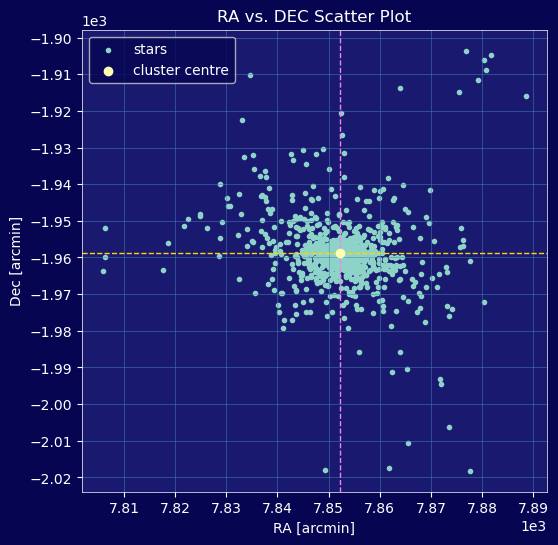

In [20]:
print(f'Projected Radii stats: \n {my_cluster["proj_radii"].describe()}')
print(f'Binned Sigma stats: \n {df_30["surface density"].describe()}')
cluster = plot_my_cluster((6,6), 'arcmin')

Based on the plot of empirical surface density vs. projected radius, as well as the statistics about my sample that I printed above, I think that a good scale of the log-Half-Normal to use would be $\sigma_0 = 10$, as that is at least the correct order of magnitude for what I think the $\Sigma_0$ should be. I was confused with this prior parameter, until I now understand that it encodes kind of my prediction for what the value should be. 

Looking at my cluster's empirical surface density and radial projection statistics as well as the plots of surface density vs. radius from Exercise 1 and the cluster scatter plot itself, some reasonable and unreasonable guesses: 

* $\Sigma_0$
    * Reasonable: (10.55, 9), Unreasonable: (1, 0.1)
* $r_c$
    * Reasonable: (0.4, 0.5), Unreasonable: (1, 7) 
* $r_t$
    * Reasonable: (5, 6), Unreasonable: (1, 10) 

Computing log probability densities for them: 

In [21]:
def Rc_prior(Rc_guess): 
    Rc_log_uniform = log_uniform(Rc_guess, 0, 1) # between 0 and 1 arcminutes
    return Rc_log_uniform

def Rt_prior(Rt_guess, Rc_guess): 
    Rt_log_uniform = log_uniform(Rt_guess, Rc_guess, 10) # between given Rc and 10 arcminutes
    return Rt_log_uniform

def sigma_prior(Sigma0_guess, sigma_scale):
    Sigma0_halfnorm = log_halfnormal(Sigma0_guess, sigma_scale)
    return Sigma0_halfnorm

In [22]:
# computing for all possibilities, where guesses are set up like 
# [[reasonable 1, reasonable 2], [unreasonable 1, unreasonable 2]]

def compute_priors_guesses(var, guesses, sigma_scale = None, Rc_Rt_guess = None):

    """ computes and reports log probability density for guesses as assigned in 2.c.ii"""

    if var == 'sigma': 
        reas_1 = sigma_prior(guesses[0][0], sigma_scale)
        reas_2 = sigma_prior(guesses[0][1], sigma_scale)
        unreas_1 = sigma_prior(guesses[1][0], sigma_scale)
        unreas_2 = sigma_prior(guesses[1][1], sigma_scale)

    elif var == 'R_c': 
        reas_1 = Rc_prior(guesses[0][0])
        reas_2 = Rc_prior(guesses[0][1])
        unreas_1 = Rc_prior(guesses[1][0])
        unreas_2 = Rc_prior(guesses[1][1])

    elif var == 'R_t':
        reas_1 = Rt_prior(guesses[0][0], Rc_Rt_guess)
        reas_2 = Rt_prior(guesses[0][1], Rc_Rt_guess)
        unreas_1 = Rt_prior(guesses[1][0], Rc_Rt_guess)
        unreas_2 = Rt_prior(guesses[1][1], Rc_Rt_guess)

    print(f'Log Probability Densities for {var} Guesses')
    print(f'Reasonable Guesses: \n {guesses[0][0]}: {reas_1} \n {guesses[0][1]}: {reas_2}')
    print(f'Unreasonable Guesses: \n {guesses[1][0]}: {unreas_1} \n {guesses[1][1]}: {unreas_2}')



In [23]:
sigma_guesses = [[10.5, 8], [1, 0.1]] 
Rc_guesses = [[0.4, 0.5], [0.001, 0.1]]
Rt_guesses = [[5, 9], [0.1, 11]]


compute_priors_guesses('sigma', sigma_guesses, sigma_scale = 10)
print(' ')
compute_priors_guesses('R_c', Rc_guesses)
print(' ')
compute_priors_guesses('R_t', Rt_guesses, Rc_Rt_guess = 0.5)

Log Probability Densities for sigma Guesses
Reasonable Guesses: 
 10.5: -3.079626445638773 
 8: -2.848376445638773
Unreasonable Guesses: 
 1: -2.533376445638773 
 0.1: -2.528426445638773
 
Log Probability Densities for R_c Guesses
Reasonable Guesses: 
 0.4: 0.0 
 0.5: 0.0
Unreasonable Guesses: 
 0.001: 0.0 
 0.1: 0.0
 
Log Probability Densities for R_t Guesses
Reasonable Guesses: 
 5: 2.2512917986064953 
 9: 2.2512917986064953
Unreasonable Guesses: 
 0.1: -inf 
 11: -inf


#### 2.c.iii. *Write a function that computes the logarithm of the joint prior probability density given an input vector of parameters.*

In [ ]:
# as if they are independent? 

def joint_prior_prob(theta, sigma_scale): 
    '''
    Function computes the joint prior probability of the parameters of central surface density, core radius and tidal radius 
    based on inputs of parameter guesses and the pre-decided scale for Sigma. 

    Parameters 
    ----------
    theta :  np.ndarray -- an array of values in order 1) central surface density, 2) 
             core radius, 3) tidal radius

    sigma_scale : float -- this is a necessary input for the half-normal distribution, 
                  for which I am typically going to use a value of 10 given 
                  an explanation above. 
                 
    Returns
    -------
    prior: float -- value of the joint probability for a given set of input parameters

    '''

    Sigma0, R_c, R_t = theta
    log_joint_prob = sigma_prior(Sigma0, sigma_scale) + Rc_prior(R_c) + Rt_prior(R_t, R_c) # just the sum because log!
    return log_joint_prob

So this is not assuming independence, because in reality, I have coded the joint probability of the tidal and core radius into the joint prior because the tidal radius is dependent on the core radius in its construction: 

$$
\log P(r_c, r_t, \Sigma_0) = \log P(r_c) + \log P(r_t|r_c) + \log P(\Sigma_0)
$$

where we have constructed log-uniform (scale invariant) priors on core radius and tidal radius, and a half-normal prior for the central surface density. 

## Exercise 3: Posterior Inference

### 3.a. *Write a function that computes the log-posterior, using the two functions for the log-likelihood and the log-prior.*

Before writing this function, I just want to remind myself of good old Bayes. Here, I am working to emulate
$$
\text{posterior} \propto \text{likelihood} \times \text{prior}
$$

where the output shall define the posterior probability of a vector of parameters given my data, which in this case, will be the count data ($N_i$), proportional to the Poisson likelihood I have defined (counting) times the prior I just set up (flat prior?)
$$
p(\theta|N_i) \propto p(N_i|\theta) \times p(\theta)
$$

and when put into log form this will give the log-posterior: 
$$
\log p(\theta|N_i) = \log p(N_i|\theta) + \log p(\theta)
$$

and when put into a big mess, actually represents this: 
$$
\log p(\theta|N_i) = \left[\sum_{j=1}^J[N_j \log \lambda_j - \lambda_j - \log(N_j!)]\right] + \Biggl[ \log P(r_c) + \log P(r_t|r_c) + \log P(\Sigma_0) \Biggr]
$$

In [140]:
# now writing log-posterior function 
def log_post(theta): 

    '''
    Function will take the input of values for joint_prior_prob and 
    convert_sigma_poisson_loglikely, hard-coding certain parameters
    and compute the log posterior based on these two computations
    
    Parameters
    ----------
    
    theta : numpy.ndarray
        to be inputted during fitting, array including (in order) 
        central surface density, core radius and tidal radius             

    Returns
    -------
    log_posterior : the log posterior for the given input parameters 
    
    '''
    
    # here, hard-coding the parameters which I do not plan to change for 
    # the rest of the notebook
    sigma_scale = 10
    #sigma_scale = 5
    #sigma_scale = 30
    R_mid = R_mid_30
    Areas = Areas_30
    Ns = Counts_30

    # define factors 
    log_joint_prior = joint_prior_prob(theta, sigma_scale)
    if not np.isfinite(log_joint_prior):
        return -np.inf # debugging purposes 
    log_likelihood = convert_Sigma_poisson_loglikely(theta, R_mid, Areas, Ns)
    
    # compute posterior 
    log_posterior = log_likelihood + log_joint_prior

    return log_posterior

### 3.b. 
*Choose an MCMC algorithm (a standard choice in astronomy/physics is the affine-invariant ensemble sampler implemented in the emcee library). Note: you are not required to write your own MCMC sampler! You are free to use any MCMC sampling library you would like. Make an initial choice for the total number of steps and the number to be discarded as burn-in steps, and record those numbers. Also record the number of chains/walkers, and any hyperparameters (i.e. parameters of the sampling process) you may have set (note: not all algorithms require you to manually set parameters).*

Okay, here I will first import the emcee library and then set some initial parameters, as per the suggested affine-invariant ensemble sampler. For walkers, I'm guessing 40 as a rule of thumb I found *online* said to have the walkers be $\geq 10 \times N_{dim}$. Using 5000 steps per chain and having a 10% burn-in with 500, for no real reason at all but needing to put numbers down. 

In [122]:
import emcee 
# parameter setting 
n_dimensions = 3 # for the three theta values
n_walkers_init = 15 # number of chains
n_steps_init = 5000 # steps per chain 
n_burned_init = 500 # burn in steps 
total_steps = n_steps_init * n_walkers_init
print('Initial Parameters for MCMC: \n----------------------------')
print(f'Walkers: {n_walkers_init}')
print(f'Steps per chain: {n_steps_init}')
print(f'Burned steps per chain: {n_burned_init}')
print(f'Total Steps: {total_steps}')


Initial Parameters for MCMC: 
----------------------------
Walkers: 15
Steps per chain: 5000
Burned steps per chain: 500
Total Steps: 75000


### 3.c. Starting positions 
*Compute starting positions: To get MCMC to run well, you’ll need to choose reasonable starting positions. Often, you use a maximum likelihood fit, or you can calculate these from the data (e.g. the mean of the last few bins makes a good starting position for the background rate). Here, choose reasonable starting positions based on summaries you can compute from your cluster profile or from what you can eyeball from your observed profile. Justify how you’ve chosen the starting positions.Then slightly randomize the starting positions for each chain by drawing from a small Gaussian (variance ~10^-2) around those starting positions.* 

*Hint: make sure that after drawing from the Gaussian, your starting points are all within the prior bounds by checking that the logprior of those starting positions is a well-defined number! You might want to generate more starting positions than you need and then simply choose a subset that is guaranteed to be within the prior bounds*

In [79]:
theta_guess

(10.557957300405828, 0.2, 5.0)

First, for picking starting positions: 
- $\Sigma_0$: I will use the background estimate based on the hint from the PDF, where 
$$ \Sigma_{0,\text{ guess}} = \text{max}(\Sigma_{\text{peak}} - \text{mean} (\Sigma_{\text{outer bins}}))$$

In [161]:
sigma_30 = Counts_30 / Areas_30
sigma_30_bg = np.mean(sigma_30[-5:])
sigma_0_guess = np.max(sigma_30 - sigma_30_bg)
print(sigma_0_guess)

10.555844576642695


The core radius in the King profile is defined where the cluster surface density drops by half. In my plots from part 1, this looks like it happens somewhere around 2 or 3. However the prior requires that the guess for the core radius be less than 1, so I will push it as high as possible into that limit for my guess. 

Then, the tidal radius needs to be less than 10, however looking at my scatter plot, it appears to be at least 10 if not more. So this too, I will guess at a high limit below the boundary of 10. 

In [162]:
first_pos_guesses = np.array([sigma_0_guess, 0.9999999999999999, 9.9999999999999999])

Now randomizing, with a variance of $10^{-2}$: 

In [163]:
rng = np.random.default_rng(33)

def get_randomized_inf_check(starting_theta, n_walkers, n_dims):
    '''Just making this in case I need to re-generate the random sample with different emcee params
    COME BACK AND ANNOTATE THIS FUNCTION
    '''
    # randomize position
    position = starting_theta + 0.1*rng.standard_normal(size=(n_walkers, n_dims)) # variance of 10^-2

    # this is a little while bit that makes sure things are within the bounds of the prior
    # and resamples if it has an infinite output 
    out_of_bounds = ~np.isfinite([joint_prior_prob(pos, 10) for pos in position])
    while np.any(out_of_bounds): # this just makes sure 
        position[out_of_bounds] = starting_theta + 0.1 * rng.standard_normal(size = (out_of_bounds.sum(), n_dims))
        out_of_bounds = ~np.isfinite([joint_prior_prob(pos, 10) for pos in position])
    
    return position

# try out randomizer

pos1 = get_randomized_inf_check(first_pos_guesses, n_walkers_init, n_dimensions)

In [164]:
pos1

array([[10.85803181,  0.89859031,  9.93078099],
       [10.52319736,  0.94767921,  9.9547961 ],
       [10.63804394,  0.9481663 ,  9.95802421],
       [10.58268757,  0.89255313,  9.9319021 ],
       [10.56593596,  0.90631159,  9.93391688],
       [10.5144788 ,  0.99582692,  9.94704216],
       [10.6114668 ,  0.92272096,  9.9519511 ],
       [10.61022203,  0.87011032,  9.91198454],
       [10.46033742,  0.94653831,  9.9079254 ],
       [10.47657232,  0.93206968,  9.79504758],
       [10.54835353,  0.92697333,  9.9773265 ],
       [10.47975224,  0.77493575,  9.94560049],
       [10.72786096,  0.91199893,  9.97863461],
       [10.49044676,  0.95176704,  9.97457819],
       [10.58478317,  0.98129977,  9.89874174]])

Now running the actual sampler, and doing it for 15 chains. 

In [141]:
# this block I am using with the help of my friend and classmate, Ana Mare

sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples = sampler.get_chain(discard = 0, flat = False)

# first run: 00:01:02

Sampler Running


100%|██████████| 5000/5000 [00:23<00:00, 209.14it/s]


In [142]:
len(samples)

5000

## Exercise 4: Diagnostics 

### 4.a. Trace Plots 

*Show trace plots for all parameters of the entire chain (with burn-in). Clearly mark the part of the chain to be discarded as burn-in.*

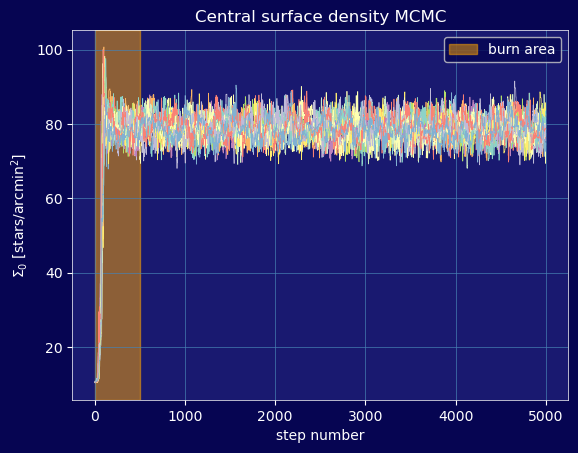

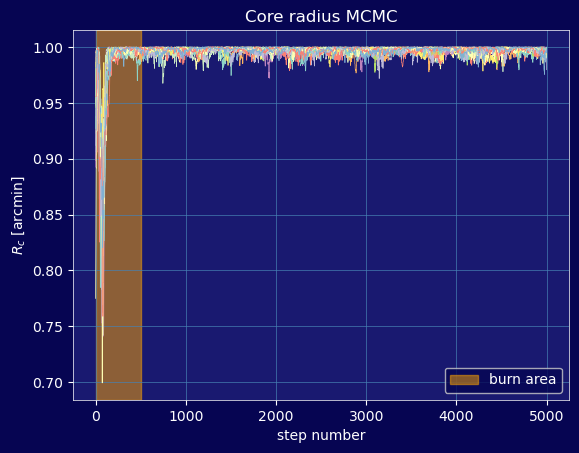

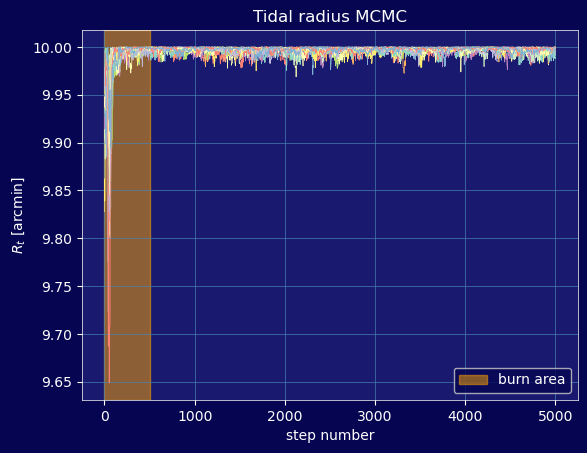

In [143]:
titles = ["Central surface density", "Core radius", "Tidal radius"]
variables = ["$\Sigma_0$", "$R_c$", "$R_t$"]
dimensions = ["stars/arcmin$^2$", "arcmin", "arcmin"]
for i in range(0, 3):
    plt.plot(samples[:, :, i], alpha = 1, linewidth = 0.5)
    plt.title(f"{titles[i]} MCMC")
    plt.xlabel("step number")
    plt.ylabel(f"{variables[i]} [{dimensions[i]}]")
    plt.axvspan(0, n_burned_init, alpha=0.5, color='orange', label = "burn area")
    plt.legend()
    plt.show()


to do: plot just one chain of the MCMC for surface density, see how it looks

*(i) Based on the trace plots, choose one of the following and justify using your trace plots:*
- *My MCMC chains are well-converged and sampling from the posterior*
- *My MCMC chains are not converged in parameters [add the relevant parameters].*

*(ii) Did you leave enough steps for burn-in? Justify your answer based on the trace plots. If you chose too few burn-in steps, adjust your numbers and re-run the MCMC chains.*

**(i)**: My MCMC chains are well-converged and sampling from the posterior
- My chains are clearly converging, however the central and tidal radius appear better converged than the surface density (though this may be just a matter of scale.) All three plots tend to a single value after burn in and adhere to a consistent variance, with no visible drift or skew that might indicate sub-structures. 


**(ii)**: I did leave enough steps for burn-in. 
- Clearly, my MCMC ran far longer than it needed to in order to converge on a value after burn-in. However, better to be safe than sorry? I intended to burn 500 in my initial guess, however in reality, I may take off a bit less than what I said (closer to 250). 

NOTE: For the surface density, the MCMC does indeed converge, but it converges at a value far higher than I guessed (and what I expected, given the initial distributions shown in Exercise 1.) It converged around a value of 80, rather than the ~10.5 I expected and guessed. This means that my model is not good. I decided to investigate (not shown). One parameter I have had hard-coded for a while is the scale parameter in the log-likelihood. I decided to change this, thinking it (10) might be too large or too small. When I ran the chains with a scale of 30, the surface density converged around 85/86 (so +6) and when I ran it with a scale of 5, it converged around 65 (-15). What I believe this means is that the posterior is very sensitive to the prior and not being constrained enough by the data (Poisson likelihood). Thus, I am almost certain this means that the posterior is degenerate with the prior parameters, particularly the $R_c$, which I (have already stated previously) believe needs to be greater than 1, and somewhere around 3. I think this means there has to be some trade-off happening between $R_c$ and $\Sigma_0$ in the joint prior distribution. $R_c$ is too small, thus $\Sigma_0$ must blow up to compensate, or something of that nature. 

In [144]:
np.mean(sampler.acceptance_fraction)

0.5468266666666667

### 4.b. Integrated autocorrelation time and effective sample size (after discarding burn-in!): 
*Compute the integrated autocorrelation time $\tau_{int}$ for each parameter and report the effective sample size $N_{eff} \approx N/\tau_{int}$. How long would you need to run your chain in order to achieve that sample? Justify your answers using the autocorrelation time. Hint: Most libraries have implemented a function to calculate the autocorrelation time, you shouldn’t need to write code for this yourself.*

In [145]:
burn_in = 250
sampler = emcee.EnsembleSampler(n_walkers_init, n_dimensions, log_post)
print("Sampler Running")
sampler.run_mcmc(pos1, n_steps_init, progress = True)
samples = sampler.get_chain(discard = burn_in, flat = False) 

Sampler Running


100%|██████████| 5000/5000 [00:23<00:00, 208.61it/s]


In [157]:
# Computing integrated autocorrelation time for each parameter
n_steps_burnout = n_steps_init - burn_in
taus = []
N_effs = []
taus_bigsample = []
for i in range(3): 
    tau = emcee.autocorr.integrated_time(samples[:,:,i], c = 5, tol = 50, quiet = False)
    N_eff = n_steps_burnout/tau
    tau_bigsample = tau*n_steps_burnout
    # these will then be an array of times in order Sigma_0, R_c, R_t
    taus.append(tau) 
    N_effs.append(N_eff)
    taus_bigsample.append(tau_bigsample)

print(f'Autocorrelation Times:\n---------------------- \nSigma_0: {taus[0]} \nR_c: {taus[1]} \nR_t: {taus[2]}\n')
print(f'Effective Sample Sizes:\n----------------------- \nSigma_0: {N_effs[0]} \nR_c: {N_effs[1]} \nR_t: {N_effs[2]}\n')
print(f'Times to achieve N_eff:\n----------------------- \nSigma_0: {taus_bigsample[0]} \nR_c: {taus_bigsample[1]} \nR_t: {taus_bigsample[2]}')


Autocorrelation Times:
---------------------- 
Sigma_0: [47.64439941] 
R_c: [57.17714975] 
R_t: [53.191022]

Effective Sample Sizes:
----------------------- 
Sigma_0: [99.69692259] 
R_c: [83.07514489] 
R_t: [89.30078463]

Times to achieve N_eff:
----------------------- 
Sigma_0: [226310.8972129] 
R_c: [271591.46133464] 
R_t: [252657.35449575]


In [158]:
import corner

oh dear! (expected)


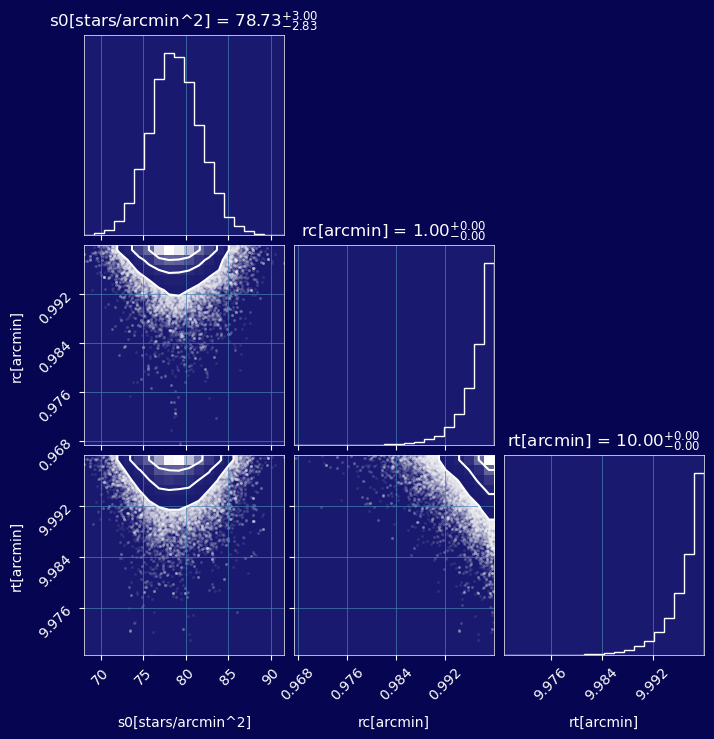

In [166]:
samples_flat = sampler.get_chain(discard = burn_in, flat = True)
labels = ["s0[stars/arcmin^2]", "rc[arcmin]", "rt[arcmin]"]
fig = corner.corner(samples_flat, labels = labels, show_titles = True)
print('oh dear! (expected)')
plt.show()